In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('healthcare_dataset.csv')
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Data Cleaning

In [ ]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                55500 non-null  object 
 1   age                 55500 non-null  int64  
 2   gender              55500 non-null  object 
 3   blood_type          55500 non-null  object 
 4   medical_condition   55500 non-null  object 
 5   date_of_admission   55500 non-null  object 
 6   doctor              55500 non-null  object 
 7   hospital            55500 non-null  object 
 8   insurance_provider  55500 non-null  object 
 9   billing_amount      55500 non-null  float64
 10  room_number         55500 non-null  int64  
 11  admission_type      55500 non-null  object 
 12  discharge_date      55500 non-null  object 
 13  medication          55500 non-null  object 
 14  test_results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [ ]:
df.isna().sum()

,0
name,0
age,0
gender,0
blood_type,0
medical_condition,0
date_of_admission,0
doctor,0
hospital,0
insurance_provider,0
billing_amount,0


In [ ]:
df.duplicated().sum()

np.int64(534)

In [ ]:
duplicates = df[df.duplicated(keep=False)]
duplicates.sort_values(by=list(df.columns))

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
42407,ABIgaIL YOung,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.568297,192,Elective,2023-01-13,Ibuprofen,Normal
54285,ABIgaIL YOung,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.568297,192,Elective,2023-01-13,Ibuprofen,Normal
26025,ALIcia taYLoR,78,Male,O+,Asthma,2022-09-18,Dawn Burton,Wright LLC,Aetna,31465.274979,149,Elective,2022-10-15,Aspirin,Inconclusive
53104,ALIcia taYLoR,78,Male,O+,Asthma,2022-09-18,Dawn Burton,Wright LLC,Aetna,31465.274979,149,Elective,2022-10-15,Aspirin,Inconclusive
42323,AMy GREEN,79,Female,B+,Obesity,2021-03-30,Brett Johnson,Taylor-Williamson,UnitedHealthcare,23402.358491,249,Elective,2021-04-27,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50070,wiLliam LEe,27,Female,O+,Arthritis,2020-01-31,Lauren Montgomery,Winters-Simon,Cigna,46229.434901,153,Elective,2020-02-13,Lipitor,Normal
27374,willIAM DUnCan,78,Female,B-,Arthritis,2019-08-04,Margaret Rice,"and Hobbs Rice, Miller",UnitedHealthcare,4537.845577,383,Elective,2019-08-17,Aspirin,Abnormal
53693,willIAM DUnCan,78,Female,B-,Arthritis,2019-08-04,Margaret Rice,"and Hobbs Rice, Miller",UnitedHealthcare,4537.845577,383,Elective,2019-08-17,Aspirin,Abnormal
6345,zaCHAry balL,85,Female,B-,Diabetes,2020-04-25,Matthew Conley,"and Morgan Jones, Matthews",Blue Cross,15207.547262,202,Emergency,2020-05-25,Penicillin,Inconclusive


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                54966 non-null  object 
 1   age                 54966 non-null  int64  
 2   gender              54966 non-null  object 
 3   blood_type          54966 non-null  object 
 4   medical_condition   54966 non-null  object 
 5   date_of_admission   54966 non-null  object 
 6   doctor              54966 non-null  object 
 7   hospital            54966 non-null  object 
 8   insurance_provider  54966 non-null  object 
 9   billing_amount      54966 non-null  float64
 10  room_number         54966 non-null  int64  
 11  admission_type      54966 non-null  object 
 12  discharge_date      54966 non-null  object 
 13  medication          54966 non-null  object 
 14  test_results        54966 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.7+ MB


In [ ]:
df['name'] = df['name'].str.lower()
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
0,bobby jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,leslie terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,danny smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrew watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrienne bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
0,bobby jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,leslie terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,danny smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrew watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrienne bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
0,bobby jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,leslie terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,danny smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrew watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrienne bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   name                54966 non-null  object        
 1   age                 54966 non-null  int64         
 2   gender              54966 non-null  object        
 3   blood_type          54966 non-null  object        
 4   medical_condition   54966 non-null  object        
 5   date_of_admission   54966 non-null  datetime64[ns]
 6   doctor              54966 non-null  object        
 7   hospital            54966 non-null  object        
 8   insurance_provider  54966 non-null  object        
 9   billing_amount      54966 non-null  float64       
 10  room_number         54966 non-null  int64         
 11  admission_type      54966 non-null  object        
 12  discharge_date      54966 non-null  datetime64[ns]
 13  medication          54966 non-null  object        


In [ ]:
df['date_of_admission'].min()

Timestamp('2019-05-08 00:00:00')

In [ ]:
df['date_of_admission'].max()

Timestamp('2024-05-07 00:00:00')

2019 - 2024

## EDA

What is the average age of admitted patients

In [ ]:
average_age = df['age'].mean()
print(f"Average Age: {average_age:.1f} years")

Average Age: 51.5 years


which age group (e.g., 20-30, 31-50, 50+) has the highest number of admissions?

In [ ]:
bins = [0, 30, 50, 100]
labels = ['Under 30', '31-50', 'Over 50']
df['Age Group'] = pd.cut(df['age'], bins=bins, labels=labels)
print("\nAdmissions by Age Group:\n", df['Age Group'].value_counts())


Admissions by Age Group:
 Age Group
Over 50     28394
31-50       16167
Under 30    10405
Name: count, dtype: int64


Which Medical Condition is the most common overall?

In [ ]:
Common_Condition = df['medical_condition'].value_counts()
print(Common_Condition)

medical_condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64


Does the prevalence of specific medical conditions differ significantly between male and female patients?

In [ ]:
(df.groupby('gender')['medical_condition'].value_counts())

gender  medical_condition
Female  Arthritis            4642
        Diabetes             4609
        Obesity              4573
        Hypertension         4569
        Cancer               4566
        Asthma               4511
Male    Diabetes             4607
        Asthma               4584
        Hypertension         4582
        Arthritis            4576
        Cancer               4574
        Obesity              4573
Name: count, dtype: int64

yes females are likley to have Arthritis and man are likely to have Diabetes

Which Insurance Provider (e.g., Medicare, Aetna, Cigna) covers the most patients in this network?

In [ ]:
(df.groupby('insurance_provider')['name'].value_counts())


insurance_provider  name             
Aetna               kimberly smith       6
                    michael williams     6
                    amanda smith         5
                    james smith          5
                    kevin miller         5
                                        ..
UnitedHealthcare    zachary santiago     1
                    zachary shaffer      1
                    zachary smith dds    1
                    zachary yates        1
                    zachary young        1
Name: count, Length: 46919, dtype: int64

/tmp/ipykernel_6007/2708548688.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=insurance_counts.index, y=insurance_counts.values, palette='viridis')


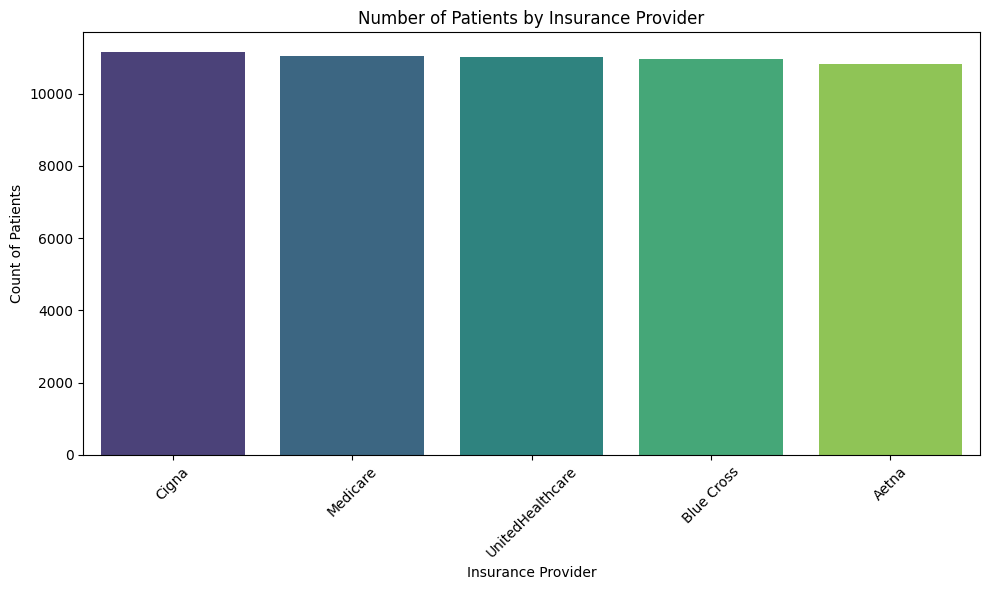

In [ ]:
insurance_counts = df['insurance_provider'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=insurance_counts.index, y=insurance_counts.values, palette='viridis')

plt.title('Number of Patients by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Count of Patients')
plt.xticks(rotation=45) # Rotates labels to make them readable
plt.tight_layout()
plt.show()

What is the average Billing Amount across the entire hospital, and which insurance provider is associated with the highest average billing amounts?

In [ ]:
print('average_billing across entire hospital =',df['billing_amount'].mean())
average_billing = df.groupby('insurance_provider')['billing_amount'].mean()
print('average_billing associated with',average_billing)

average_billing across entire hospital = 25544.306284383965
average_billing associated with insurance_provider
Aetna               25549.689648
Blue Cross          25603.460603
Cigna               25525.998670
Medicare            25628.320208
UnitedHealthcare    25414.506208
Name: billing_amount, dtype: float64


/tmp/ipykernel_6007/2680383639.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_billing.index, y=average_billing.values, palette='magma')


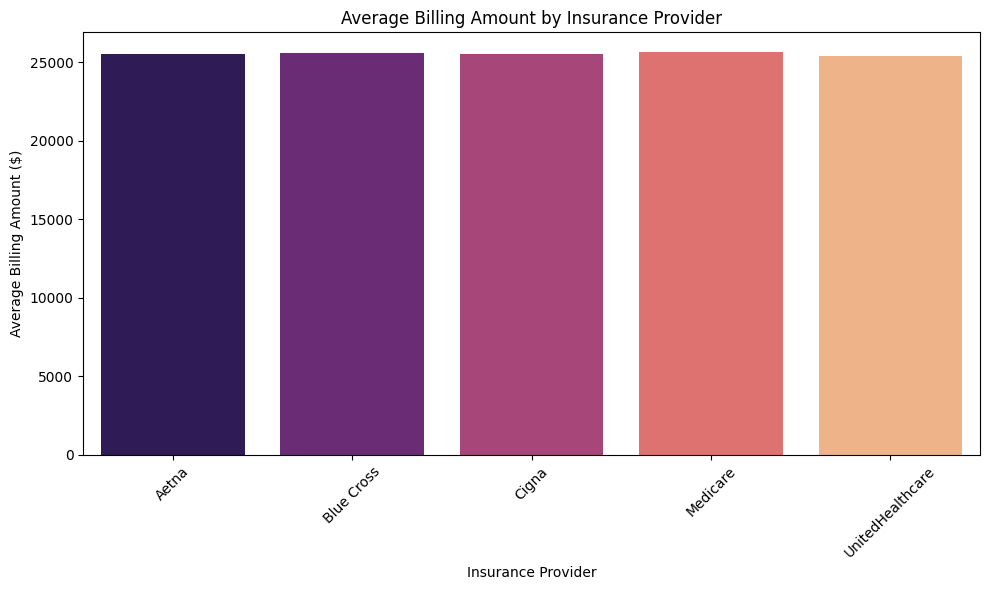

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=average_billing.index, y=average_billing.values, palette='magma')

plt.title('Average Billing Amount by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Average Billing Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Which medical condition results in the highest average billing amount?

In [ ]:
(df.groupby('medical_condition')['billing_amount'].mean(). sort_values(ascending=False))

,billing_amount
medical_condition,
Obesity,25804.361902
Diabetes,25660.478635
Asthma,25633.461696
Arthritis,25511.783246
Hypertension,25503.058720
Cancer,25152.322947


By calculating the difference between Discharge Date and Date of Admission, what is the average length of a patient's stay?

In [ ]:
patient_stay = df['discharge_date'] - df['date_of_admission']
average_stay = patient_stay.mean()
print(f"Average Patient Stay: {average_stay}")

Average Patient Stay: 15 days 11:58:58.696648837


What percentage of admissions are Emergency, Urgent, or Elective? Does the admission type impact the length of stay?

admission_type
Elective     15.511178
Emergency    15.584134
Urgent       15.403839
Name: length_of_stay, dtype: float64


/tmp/ipykernel_6007/4064255962.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_stay.index, y=avg_stay.values, palette='viridis')


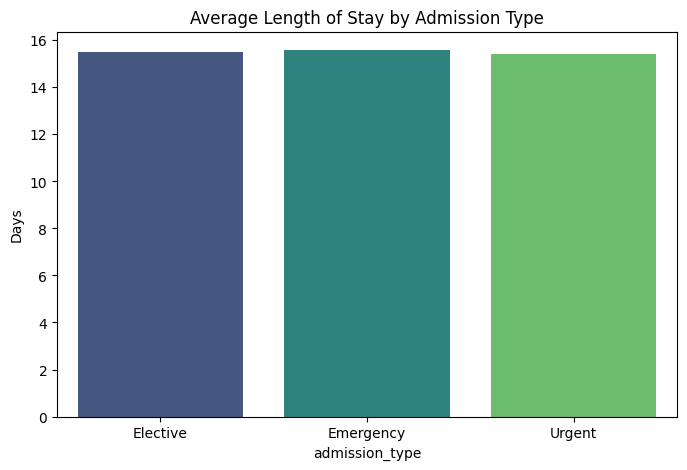

In [ ]:
df['length_of_stay'] = (df['discharge_date'] - df['date_of_admission']).dt.days

avg_stay = df.groupby('admission_type')['length_of_stay'].mean()
print(avg_stay)

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_stay.index, y=avg_stay.values, palette='viridis')
plt.title('Average Length of Stay by Admission Type')
plt.ylabel('Days')
plt.show()

What is the most common Medication prescribed for patients with an 'Abnormal' Test Result?

In [ ]:
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results,Age Group,length_of_stay
0,bobby jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,Under 30,2
1,leslie terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,Over 50,6
2,danny smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,Over 50,15
3,andrew watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,Under 30,30
4,adrienne bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,31-50,20


In [ ]:
abnormal_results = df[df['test_results'] == 'Abnormal']
top_meds_abnormal = abnormal_results['medication'].value_counts()
print("\nTop Meds for Abnormal Results:\n", top_meds_abnormal)


Top Meds for Abnormal Results:
 medication
Ibuprofen      3711
Aspirin        3700
Paracetamol    3695
Lipitor        3670
Penicillin     3661
Name: count, dtype: int64


##Final Insights Found


##**Patient Demographics & AdmissionsAverage Age:**

The average age of admitted patients in this network is 51.5 years.Age Distribution: The majority of patients belong to the "Over 50" age group ($28,394$ admissions), followed by the "31-50" group ($16,167$ admissions), and the "Under 30" group ($10,405$ admissions).Gender Trends in Medical Conditions: There are clear differences in the prevalence of medical conditions by gender:Female patients are more likely to have Arthritis.Male patients are more likely to have Diabetes.

##**Hospital Operations & EfficiencyAdmission Balance:**

Admissions are distributed almost evenly across all types: Elective ($33.6\%$), Urgent ($33.5\%$), and Emergency ($32.9\%$).Length of Stay: The admission type does not significantly impact the length of stay, as the average stay is consistent across all three categories (approximately $15.4$ to $15.6$ days).

##**Financial & Treatment InsightsAverage Billing:**

The average billing amount across the entire hospital is approximately $25,544$.Billing by Condition: While billing is generally consistent, Obesity ($25,804$ avg) and Diabetes ($25,660$ avg) are associated with the highest average billing amounts, while Cancer patients have the lowest average billing ($25,152$ avg).Medication & Testing: For patients with 'Abnormal' test results, the most commonly prescribed medication is Ibuprofen, though Aspirin, Paracetamol, Lipitor, and Penicillin are prescribed at very similar rates for these patients.